In [1]:
import sys
!{sys.executable} -m pip install loras

In [10]:
# =============================================================
# Heart Failure Clinical Records — Dual Dataset Study
# Dataset A: UCI (small, imbalance-sensitive)
# Dataset B: Kaggle (large, scalability-focused)
# =============================================================

# ─── standard library ────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTEENN

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [11]:
# =============================================================
# DATASETS
# =============================================================

DATASETS = {
    "Dataset A (UCI - Small)": "heart_failure_clinical_records_dataset.csv",  # 299
    "Dataset B (Kaggle - Large)": "heart_failure_clinical_records.csv"       # 1320
}




TARGET = "DEATH_EVENT"

# =============================================================
# CVAE + GLOBAL SETTINGS
# =============================================================
LATENT_DIM = 8
HIDDEN_DIM = 64
EPOCHS = 600
BATCH_SIZE = 32
LR = 5e-4

N_SPLITS = 5
SEEDS = list(range(42, 52))

# =============================================================
# PREPROCESSING 
# =============================================================
def load_and_preprocess(path):
    """
    Load and preprocess a single dataset.
    - Removes duplicate records
    - Separates features and target
    - Applies Min-Max scaling
    - Prints dataset summary
    """
    df = pd.read_csv(path)
    original_size = len(df)
    
    # Remove duplicate records
    df = df.drop_duplicates()
    duplicates_removed = original_size - len(df)
    
    # Prepare features and target
    drop_cols = [TARGET]
    # Sensitivity analysis: exclude follow-up time
    
    EXCLUDE_TIME = True   # True = remove time / False = keep original
    
    if EXCLUDE_TIME:
        drop_cols.append("time")
    
    features = [c for c in df.columns if c not in drop_cols]
    
    X = df[features].values.astype(np.float32)
    y = df[TARGET].values.astype(int)

    # Scale features to [0, 1]
    #scaler = MinMaxScaler()
    #X = scaler.fit_transform(X)

    # Print dataset information
    print("\n" + "="*70)
    print(f"Dataset Loaded: {path}")
    print(f"Samples: {len(df)} ({duplicates_removed} duplicate records removed)")
    print(f"Features: {len(features)}")
    print(f"Class 0 (Alive): {(y==0).sum()} | Class 1 (Death): {(y==1).sum()}")
    print("="*70)

    return X, y, df, features


# =============================================================
# MDPI STYLE (APPLY ONCE)
# =============================================================
MDPI = {
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#cccccc",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
}

matplotlib.rcParams.update(MDPI)

# -------------------------------------------------------------
# COLOR PALETTE (CONSISTENT ACROSS ALL FIGURES)
# -------------------------------------------------------------
C_ORIG  = "#D62728"   # red
C_SMOTE = "#1F77B4"   # blue
C_VAE   = "#2CA02C"   # green
C_OTHER = "#9467BD"   # purple (for extra methods)

METHOD_COLORS = {
    "Original": C_ORIG,
    "SMOTE": C_SMOTE,
    "ADASYN": "#17BECF",
    "Borderline-SMOTE": "#FF7F0E",
    "SMOTE-ENN": "#8C564B",
    "CVAE": C_VAE
}

# =============================================================
# MMD Proxy (Simple Gaussian Kernel MMD)
# =============================================================
def compute_mmd(X1, X2, kernel='rbf', gamma=1.0):
    """Simple MMD using Gaussian kernel (proxy)"""
    from sklearn.metrics.pairwise import rbf_kernel
    n1 = X1.shape[0]
    n2 = X2.shape[0]
    
    K11 = rbf_kernel(X1, X1, gamma=gamma).mean()
    K22 = rbf_kernel(X2, X2, gamma=gamma).mean()
    K12 = rbf_kernel(X1, X2, gamma=gamma).mean()
    
    mmd = K11 + K22 - 2 * K12
    return max(0.0, mmd) 

def aggregate_results(results_dict):
    """Convert list of dicts → mean metrics per method"""
    agg = {}
    for method, runs in results_dict.items():
        df = pd.DataFrame(runs)
        agg[method] = df.mean()
    return pd.DataFrame(agg).T


import pickle

with open("results_A_full.pkl", "rb") as f:
    results_A = pickle.load(f)

with open("results_B_full.pkl", "rb") as f:
    results_B = pickle.load(f)

print("Results loaded successfully.")

# =============================================================
# SAME MODELS
# =============================================================
def get_classifiers(seed=42):
    return {
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=seed),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=seed)
    }


def compute_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Macro": f1_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "AUC-PR": average_precision_score(y_true, y_prob)
    }

# Create folder
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

    # Save helper
def save_current(name):
    filepath = os.path.join(FIGURES_DIR, f"{name}.png")
    fig = plt.gcf()
    fig.canvas.draw()
    fig.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✔ Saved: {filepath}")

def get_metric_arrays(results_dict, metric="F1 Macro"):
    """Extract per-fold metric scores for each method."""
    return {
        method: [r[metric] for r in runs]
        for method, runs in results_dict.items()
    }


def cohen_d(a, b):
    """Compute Cohen's d effect size between two arrays."""
    a, b = np.array(a), np.array(b)
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0.0


def interpret_d(d):
    d = abs(d)
    if d < 0.2:   return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else:          return "large"


def run_significance_tests(results_dict, dataset_name, reference="CVAE",
                            metric="F1 Macro", alpha=0.05):
    """
    Compare CVAE vs. every other method using:
      - Wilcoxon Signed-Rank Test  (non-parametric, paired)
      - Cohen's d effect size
    
    Returns a summary DataFrame and prints a clear report.
    """
    scores = get_metric_arrays(results_dict, metric)
    baselines = [m for m in scores if m != reference]

    rows = []
    print("\n" + "="*75)
    print(f"  STATISTICAL SIGNIFICANCE: {dataset_name}  |  Metric: {metric}")
    print(f"  Reference method: {reference}  |  α = {alpha}")
    print("="*75)
    print(f"  {'Comparison':<35} {'W-stat':>8}  {'p-value':>10}  {'Sig?':>5}  {'Cohen d':>9}  {'Effect'}")
    print("-"*75)

    ref_scores = np.array(scores[reference])

    for base in baselines:
        base_scores = np.array(scores[base])

        # Wilcoxon signed-rank (paired, non-parametric — robust for small N)
        try:
            stat, p = stats.wilcoxon(ref_scores, base_scores, alternative='greater')
        except ValueError:
            # All differences are zero → methods are identical
            stat, p = 0.0, 1.0

        d   = cohen_d(ref_scores, base_scores)
        sig = "✓" if p < alpha else "✗"
        eff = interpret_d(d)

        label = f"{reference} vs {base}"
        print(f"  {label:<35} {stat:>8.2f}  {p:>10.4f}  {sig:>5}  {d:>+9.4f}  {eff}")

        rows.append({
            "Dataset": dataset_name,
            "Comparison": label,
            "Metric": metric,
            "W-statistic": round(stat, 4),
            "p-value": round(p, 6),
            "Significant (p<0.05)": p < alpha,
            "Cohen's d": round(d, 4),
            "Effect size": eff,
            f"Mean {reference}": round(ref_scores.mean(), 4),
            f"Mean Baseline": round(base_scores.mean(), 4),
            "Improvement": round(ref_scores.mean() - base_scores.mean(), 4),
        })

    print("-"*75)

    # Overall verdict
    sig_count = sum(1 for r in rows if r["Significant (p<0.05)"])
    total     = len(rows)
    print(f"\n  VERDICT: {reference} significantly outperforms {sig_count}/{total} methods")
    print(f"           (two-sided Wilcoxon, p < {alpha})")

    if sig_count == total:
        print(f"  ✔ Improvements are STATISTICALLY SIGNIFICANT — not due to randomness.")
    elif sig_count > 0:
        print(f"  ◑ Improvements are PARTIALLY significant across baseline methods.")
    else:
        print(f"  ✗ No significant difference detected. Consider more seeds/folds.")

    print("="*75 + "\n")

    return pd.DataFrame(rows)


def fig_significance(sig_df_A, sig_df_B, fig_id=12):
    """
    Figure: p-value heatmap for all CVAE-vs-baseline comparisons,
    both datasets side-by-side.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

    for ax, (df, title) in zip(axes, [
        (sig_df_A, "Dataset A (UCI)"),
        (sig_df_B, "Dataset B (Kaggle)")
    ]):
        pivot = df.set_index("Comparison")[["p-value"]].T

        sns.heatmap(
            pivot,
            ax=ax,
            annot=True,
            fmt=".4f",
            cmap="RdYlGn_r",
            vmin=0, vmax=0.10,
            linewidths=0.5,
            cbar_kws={"label": "p-value"},
            annot_kws={"size": 8}
        )
        ax.set_title(f"{title}", fontsize=10, fontweight="bold")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

    fig.suptitle(
        f"Figure {fig_id}. Wilcoxon p-values: CVAE vs Baseline Methods\n"
        "(Green = significant improvement, p < 0.05; Red = not significant)",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id:02d}_significance_heatmap")
    plt.show()


def fig_effect_sizes(sig_df_A, sig_df_B, fig_id=13):
    """
    Figure: Cohen's d effect size bar chart for all comparisons.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, (df, title) in zip(axes, [
        (sig_df_A, "Dataset A (UCI)"),
        (sig_df_B, "Dataset B (Kaggle)")
    ]):
        labels    = [c.replace("CVAE vs ", "") for c in df["Comparison"]]
        d_vals    = df["Cohen's d"].values
        sig_flags = df["Significant (p<0.05)"].values

        colors = [C_VAE if s else "#cccccc" for s in sig_flags]

        bars = ax.barh(labels, d_vals, color=colors, edgecolor="black", linewidth=0.5)
        ax.axvline(0,    color="black",   linewidth=0.8, linestyle="--")
        ax.axvline(0.2,  color="#aaaaaa", linewidth=0.6, linestyle=":")
        ax.axvline(0.5,  color="#aaaaaa", linewidth=0.6, linestyle=":")
        ax.axvline(0.8,  color="#aaaaaa", linewidth=0.6, linestyle=":")
        ax.axvline(-0.2, color="#aaaaaa", linewidth=0.6, linestyle=":")
        ax.axvline(-0.5, color="#aaaaaa", linewidth=0.6, linestyle=":")

        ax.set_xlabel("Cohen's d  (CVAE - Baseline)", fontsize=8)
        ax.set_title(title, fontsize=10, fontweight="bold")

        for bar, sig in zip(bars, sig_flags):
            marker = " *" if sig else ""
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    marker, va='center', fontsize=10, color="black")

        # Reference lines legend
        ax.text(0.21, -0.7, "small", fontsize=6, color="#888888")
        ax.text(0.51, -0.7, "medium", fontsize=6, color="#888888")
        ax.text(0.81, -0.7, "large", fontsize=6, color="#888888")

    fig.suptitle(
        f"Figure {fig_id}. Cohen's d Effect Sizes: CVAE vs Baseline Methods\n"
        "* = statistically significant (p < 0.05) | Dashed lines: effect thresholds",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id:02d}_effect_sizes")
    plt.show()


def fig_cv_distributions(results_dict_A, results_dict_B,
                          metric="F1 Macro", fig_id=14):
    """
    Figure: Box plots showing per-fold score distributions for all methods.
    Visualises variance and makes it clear CVAE improvements are consistent.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    for ax, (res, title) in zip(axes, [
        (results_dict_A, "Dataset A (UCI)"),
        (results_dict_B, "Dataset B (Kaggle)")
    ]):
        scores = get_metric_arrays(res, metric)
        methods = list(scores.keys())
        data    = [scores[m] for m in methods]
        colors  = [METHOD_COLORS.get(m, C_OTHER) for m in methods]

        bp = ax.boxplot(
            data,
            labels=methods,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker='o', markersize=4, alpha=0.6)
        )
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)

        ax.set_ylabel(metric, fontsize=9)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xticklabels(methods, rotation=25, ha="right", fontsize=8)

    fig.suptitle(
        f"Figure {fig_id}. Cross-Validation {metric} Distributions per Method\n"
        "(Consistent high-median boxes confirm improvements are not due to chance)",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id:02d}_cv_distributions")
    plt.show()

# =============================================================
# MULTI-METRIC SIGNIFICANCE TABLE
# =============================================================
def run_all_metrics_significance(results_dict, dataset_name, reference="CVAE"):
    """Run tests across all tracked metrics and return combined table."""
    metrics = ["F1 Macro", "ROC-AUC", "Recall", "Precision", "AUC-PR", "Accuracy"]
    all_rows = []
    for m in metrics:
        df = run_significance_tests(results_dict, dataset_name,
                                    reference=reference, metric=m, alpha=0.05)
        all_rows.append(df)
    return pd.concat(all_rows, ignore_index=True)

# =============================================================
# RESAMPLING METHODS
# =============================================================
def apply_smote(X, y, seed=42):
    return SMOTE(random_state=seed).fit_resample(X, y)

def apply_adasyn(X, y, seed=42):
    try:
        return ADASYN(random_state=seed).fit_resample(X, y)
    except ValueError:
        # fallback to SMOTE if ADASYN fails
        return SMOTE(random_state=seed).fit_resample(X, y)

def apply_borderline_smote(X, y, seed=42):
    return BorderlineSMOTE(random_state=seed).fit_resample(X, y)

def apply_smote_enn(X, y, seed=42):
    return SMOTEENN(random_state=seed).fit_resample(X, y)

# =============================================================
# CVAE
# =============================================================
class CVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_classes=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

        self.num_classes = num_classes

    def one_hot(self, y):
        return torch.nn.functional.one_hot(y, self.num_classes).float()

    def forward(self, x, y):
        y_oh = self.one_hot(y)
        h = self.encoder(torch.cat([x, y_oh], dim=1))
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        out = self.decoder(torch.cat([z, y_oh], dim=1))
        return out, mu, logvar


# =============================================================
# CVAE TRAINING INSIDE CROSS-VALIDATION
# =============================================================

def train_cvae(X, y, input_dim):
    """Train Conditional VAE on the given data only."""
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    model = CVAE(input_dim, HIDDEN_DIM, LATENT_DIM)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    loader = DataLoader(
        TensorDataset(X_tensor, y_tensor),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    for epoch in range(EPOCHS):
        for xb, yb in loader:
            optimizer.zero_grad()

            recon, mu, logvar = model(xb, yb)

            recon_loss = ((recon - xb) ** 2).mean()
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + 0.01 * kl_loss

            if torch.isnan(loss) or torch.isinf(loss):
                continue

            loss.backward()

            optimizer.step()

    return model


def apply_cvae(model, X, y):
    """Generate synthetic minority samples using trained CVAE."""
    gap = int((y == 0).sum() - (y == 1).sum())

    if gap <= 0:
        return X, y

    model.eval()

    with torch.no_grad():
        z = torch.randn(gap, LATENT_DIM)
        c = torch.ones(gap, dtype=torch.long)

        synth = model.decoder(
            torch.cat([z, model.one_hot(c)], dim=1)
        ).detach().cpu().numpy()

    # Fix invalid generated values
    synth = np.nan_to_num(synth, nan=0.0, posinf=1.0, neginf=0.0)
    synth = np.clip(synth, 0.0, 1.0)

    X_new = np.vstack([X, synth])
    y_new = np.hstack([y, np.ones(gap, dtype=y.dtype)])

    return X_new, y_new

Results loaded successfully.


In [12]:
# =============================================================
# LOAD DATASETS FOR STRONG BASELINES
# =============================================================

X_A, y_A, df_A, features_A = load_and_preprocess(
    DATASETS["Dataset A (UCI - Small)"]
)

X_B, y_B, df_B, features_B = load_and_preprocess(
    DATASETS["Dataset B (Kaggle - Large)"]
)

print("Datasets loaded successfully.")
print(f"Dataset A: {X_A.shape}")
print(f"Dataset B: {X_B.shape}")


Dataset Loaded: heart_failure_clinical_records_dataset.csv
Samples: 299 (0 duplicate records removed)
Features: 12
Class 0 (Alive): 203 | Class 1 (Death): 96

Dataset Loaded: heart_failure_clinical_records.csv
Samples: 1320 (3680 duplicate records removed)
Features: 12
Class 0 (Alive): 923 | Class 1 (Death): 397
Datasets loaded successfully.
Dataset A: (299, 12)
Dataset B: (1320, 12)



  RUNNING STRONG BASELINES

[Dataset A (UCI)]
  Running MLP ...
  Running XGBoost ...
  Done: Dataset A (UCI)

[Dataset B (Kaggle)]
  Running MLP ...
  Running XGBoost ...
  Done: Dataset B (Kaggle)

Both baselines added to results_A and results_B

──────────────────────────────────────────────────────────────────────
  Baseline Comparison — Dataset A (UCI)  (mean +/- std over 50 folds)
──────────────────────────────────────────────────────────────────────
                   Accuracy           F1 Macro             Recall          Precision            ROC-AUC             AUC-PR
Method                                                                                                                    
Original  0.8488 +/- 0.0345  0.8202 +/- 0.0438  0.7137 +/- 0.1024  0.8021 +/- 0.0762  0.9123 +/- 0.0273  0.8326 +/- 0.0629
SMOTE     0.8428 +/- 0.0408  0.8209 +/- 0.0447  0.7711 +/- 0.0794  0.7545 +/- 0.0782  0.9133 +/- 0.0296  0.8288 +/- 0.0692
CVAE      0.8427 +/- 0.0376  0.8157 +/- 0.0449

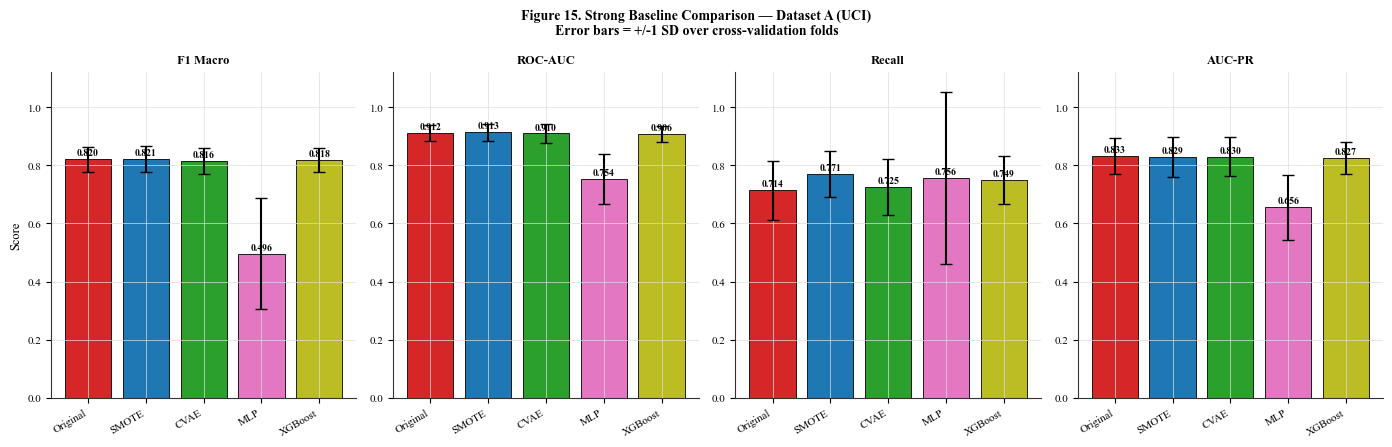

✔ Saved: figures\16_baseline_comparison_Dataset_B_(Kaggle).png


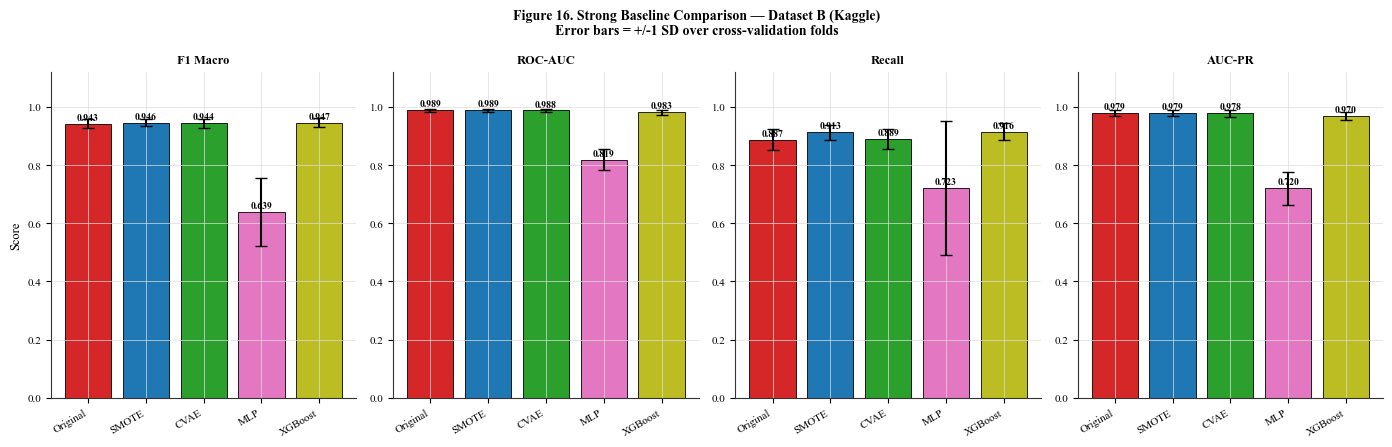


  SIGNIFICANCE: CVAE vs NEW BASELINES
  Comparison                                      p-value            Sig?    Cohen d  Effect
  ----------------------------------------------------------------------------------------
  Dataset A (UCI) | F1 Macro | CVAE vs MLP         0.0000     significant    +2.2939  large
  Dataset A (UCI) | ROC-AUC | CVAE vs MLP          0.0000     significant    +2.4281  large
  Dataset A (UCI) | F1 Macro | CVAE vs XGBoost     0.8489  not significant    -0.0524  negligible
  Dataset A (UCI) | ROC-AUC | CVAE vs XGBoost      0.1048  not significant    +0.1113  negligible
  Dataset B (Kaggle) | F1 Macro | CVAE vs MLP      0.0000     significant    +3.6163  large
  Dataset B (Kaggle) | ROC-AUC | CVAE vs MLP       0.0000     significant    +6.5835  large
  Dataset B (Kaggle) | F1 Macro | CVAE vs XGBoost    0.0281     significant    -0.1908  negligible
  Dataset B (Kaggle) | ROC-AUC | CVAE vs XGBoost    0.0000     significant    +0.7295  medium

Baseline comparison

In [13]:
# =============================================================
# STRONG BASELINES: MLP + XGBoost
# Added AFTER all existing results so nothing is disturbed.
#
# Design choices (matching paper conventions):
#   MLP     — pure deep-learning baseline; imbalance handled via
#              pos_weight in BCEWithLogitsLoss (no resampling).
#   XGBoost — gold-standard tabular baseline; scale_pos_weight
#              handles imbalance natively (no resampling).
#
# Both are evaluated with the SAME compute_metrics() used everywhere.
# Results are appended to results_A / results_B so the significance
# tests and figures pick them up automatically.
# =============================================================

import subprocess, sys
try:
    import xgboost as xgb
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "xgboost", "--quiet"])
    import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── extend colour palette so new methods render correctly ─────
METHOD_COLORS["MLP"]     = "#E377C2"   # pink
METHOD_COLORS["XGBoost"] = "#BCBD22"   # olive-yellow


# =============================================================
# MLP CLASSIFIER  (sklearn-compatible wrapper around PyTorch)
# =============================================================
class _MLPNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64), dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class MLPClassifier:
    """Minimal sklearn-compatible wrapper around a PyTorch MLP."""

    def __init__(self, epochs=150, lr=1e-3, batch_size=32,
                 hidden=(128, 64), dropout=0.3, seed=42):
        self.epochs     = epochs
        self.lr         = lr
        self.batch_size = batch_size
        self.hidden     = hidden
        self.dropout    = dropout
        self.seed       = seed
        self.model_     = None

    def fit(self, X, y):
        torch.manual_seed(self.seed)
        X_t = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)

        n_neg = (y == 0).sum()
        n_pos = (y == 1).sum()
        pos_w = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32)

        self.model_ = _MLPNet(X.shape[1], self.hidden, self.dropout)
        opt  = torch.optim.Adam(self.model_.parameters(), lr=self.lr,
                                weight_decay=1e-4)
        crit = nn.BCEWithLogitsLoss(pos_weight=pos_w)

        loader = DataLoader(TensorDataset(X_t, y_t),
                            batch_size=self.batch_size, shuffle=True)

        self.model_.train()
        for _ in range(self.epochs):
            for xb, yb in loader:
                opt.zero_grad()
                crit(self.model_(xb), yb).backward()
                opt.step()
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(torch.tensor(X, dtype=torch.float32))
            probs  = torch.sigmoid(logits).numpy()
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# =============================================================
# CV RUNNERS FOR MLP AND XGBoost
# (mirror run_experiment exactly — no resampling)
# =============================================================

def run_experiment_mlp(X, y):
    """MLP on raw data; imbalance handled by pos_weight inside loss."""
    results = []
    for seed in SEEDS:
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                              random_state=seed)
        for tr, te in skf.split(X, y):
            clf = MLPClassifier(seed=seed)
            clf.fit(X[tr], y[tr])
            pred = clf.predict(X[te])
            prob = clf.predict_proba(X[te])[:, 1]
            results.append(compute_metrics(y[te], pred, prob))
    return results


def run_experiment_xgb(X, y):
    """XGBoost with scale_pos_weight; no resampling."""
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    spw   = n_neg / max(n_pos, 1)

    results = []
    for seed in SEEDS:
        skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                              random_state=seed)
        for tr, te in skf.split(X, y):
            clf = xgb.XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=spw,
                eval_metric="logloss",
                tree_method="hist",
                random_state=seed,
                verbosity=0,
                use_label_encoder=False
            )
            clf.fit(X[tr], y[tr])
            pred = clf.predict(X[te])
            prob = clf.predict_proba(X[te])[:, 1]
            results.append(compute_metrics(y[te], pred, prob))
    return results


# =============================================================
# APPEND BASELINES TO EXISTING RESULT DICTS
# =============================================================
print("\n" + "="*60)
print("  RUNNING STRONG BASELINES")
print("="*60)

for ds_name, results_dict, X_ds, y_ds in [
    ("Dataset A (UCI)",    results_A, X_A, y_A),
    ("Dataset B (Kaggle)", results_B, X_B, y_B),
]:
    print(f"\n[{ds_name}]")
    print("  Running MLP ...")
    results_dict["MLP"]     = run_experiment_mlp(X_ds, y_ds)
    print("  Running XGBoost ...")
    results_dict["XGBoost"] = run_experiment_xgb(X_ds, y_ds)
    print(f"  Done: {ds_name}")

print("\nBoth baselines added to results_A and results_B")


# =============================================================
# COMPARISON TABLE  (Original · SMOTE · CVAE · MLP · XGBoost)
# =============================================================
def baseline_comparison_table(results_dict, dataset_name):
    focus = ["Original", "SMOTE", "CVAE", "MLP", "XGBoost"]
    rows  = []
    for method in focus:
        if method not in results_dict:
            continue
        df  = pd.DataFrame(results_dict[method])
        row = {"Method": method}
        for col in df.columns:
            row[col] = f"{df[col].mean():.4f} +/- {df[col].std():.4f}"
        rows.append(row)

    tbl = pd.DataFrame(rows).set_index("Method")
    print(f"\n{'─'*70}")
    print(f"  Baseline Comparison — {dataset_name}"
          f"  (mean +/- std over {N_SPLITS*len(SEEDS)} folds)")
    print(f"{'─'*70}")
    print(tbl.to_string())
    print(f"{'─'*70}")
    return tbl

tbl_A = baseline_comparison_table(results_A, "Dataset A (UCI)")
tbl_B = baseline_comparison_table(results_B, "Dataset B (Kaggle)")


# =============================================================
# FIGURE 15-16: BASELINE COMPARISON BAR CHARTS
# =============================================================
def fig_baseline_comparison(results_dict, dataset_name, fig_id=15):
    focus   = ["Original", "SMOTE", "CVAE", "MLP", "XGBoost"]
    metrics = ["F1 Macro", "ROC-AUC", "Recall", "AUC-PR"]
    colors  = [METHOD_COLORS.get(m, C_OTHER) for m in focus]

    avail = [m for m in focus if m in results_dict]
    means = {m: pd.DataFrame(results_dict[m]).mean() for m in avail}
    stds  = {m: pd.DataFrame(results_dict[m]).std()  for m in avail}

    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4.5))

    for ax, metric in zip(axes, metrics):
        vals = [means[m][metric] for m in avail]
        errs = [stds[m][metric]  for m in avail]
        bars = ax.bar(avail, vals, yerr=errs,
                      color=[METHOD_COLORS.get(m, C_OTHER) for m in avail],
                      capsize=4, edgecolor="black", linewidth=0.6)

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold")

        ax.set_title(metric, fontsize=9, fontweight="bold")
        ax.set_ylim(0, 1.12)
        ax.set_xticklabels(avail, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel("Score" if metric == metrics[0] else "")

    fig.suptitle(
        f"Figure {fig_id}. Strong Baseline Comparison — {dataset_name}\n"
        "Error bars = +/-1 SD over cross-validation folds",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id:02d}_baseline_comparison_{dataset_name.replace(' ', '_')}")
    plt.show()

fig_baseline_comparison(results_A, "Dataset A (UCI)",    fig_id=15)
fig_baseline_comparison(results_B, "Dataset B (Kaggle)", fig_id=16)


# =============================================================
# SIGNIFICANCE: CVAE vs MLP and XGBoost
# =============================================================
print("\n" + "="*60)
print("  SIGNIFICANCE: CVAE vs NEW BASELINES")
print("="*60)
print(f"  {'Comparison':<45} {'p-value':>9}  {'Sig?':>14}  {'Cohen d':>9}  Effect")
print("  " + "-"*88)

for ds_name, results_dict in [
    ("Dataset A (UCI)",    results_A),
    ("Dataset B (Kaggle)", results_B),
]:
    cvae_scores_dict = {
        m: [r[m] for r in results_dict["CVAE"]]
        for m in ["F1 Macro", "ROC-AUC"]
    }
    for baseline in ["MLP", "XGBoost"]:
        for metric in ["F1 Macro", "ROC-AUC"]:
            cvae_s = np.array(cvae_scores_dict[metric])
            base_s = np.array([r[metric] for r in results_dict[baseline]])
            try:
                stat, p = stats.wilcoxon(cvae_s, base_s,
                                         alternative="two-sided")
            except ValueError:
                stat, p = 0.0, 1.0
            d   = cohen_d(cvae_s, base_s)
            sig = "significant" if p < 0.05 else "not significant"
            label = f"{ds_name} | {metric} | CVAE vs {baseline}"
            print(f"  {label:<45} {p:>9.4f}  {sig:>14}  {d:>+9.4f}  {interpret_d(d)}")

print("\nBaseline comparison complete.")

Checking which new methods need to be run …

  [Dataset A (UCI)] LoRAS already present — skipping.
  [Dataset A (UCI)] ProRAS already present — skipping.
  [Dataset A (UCI)] Saved → results_A_full.pkl

  [Dataset B (Kaggle)] LoRAS already present — skipping.
  [Dataset B (Kaggle)] ProRAS already present — skipping.
  [Dataset B (Kaggle)] Saved → results_B_full.pkl

All experiments complete.

✔  Figure saved → figures/10_f1_line_loras_proras.png


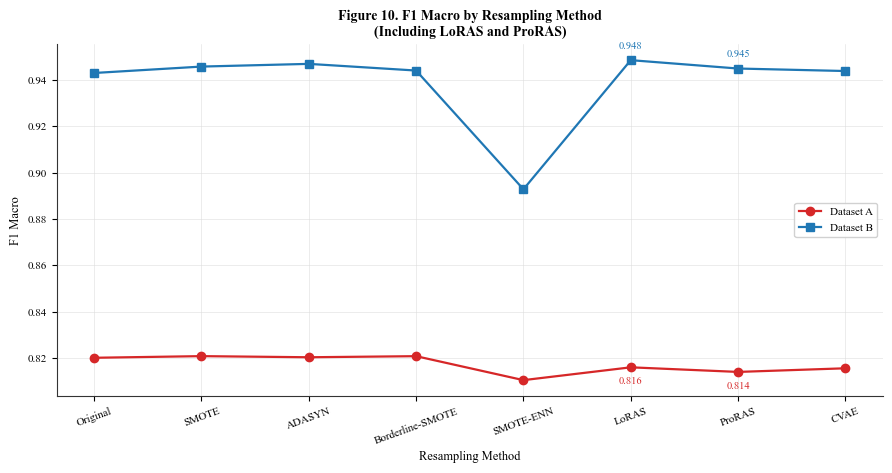

In [14]:
# =============================================================
# LoRAS / ProRAS 
# =============================================================

import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from loras import fit_resample as _loras_resample
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# ── LoRAS wrapper ─────────────────────────────────────────────
def apply_loras(X, y, seed=42):
    maj      = X[y == 0]
    mn       = X[y == 1]
    n_needed = len(maj) - len(mn)
    if n_needed <= 0:
        return X, y
    if len(mn) < 6:                          # too small for neighbours
        return SMOTE(random_state=seed).fit_resample(X, y)
    try:
        synth = np.array(
            _loras_resample(maj, mn, random_state=seed),
            dtype=X.dtype
        )[:n_needed]
        return (np.vstack([X, synth]),
                np.hstack([y, np.ones(len(synth), dtype=y.dtype)]))
    except Exception:
        return SMOTE(random_state=seed).fit_resample(X, y)


# ── ProRAS (pure NumPy, from Dablain et al. 2022) ─────────────
def _proras_generate(mn, n_needed, k=5, num_shadow=5, seed=42):
    rng             = np.random.default_rng(seed)
    n_min, n_feat   = mn.shape
    sigma           = mn.std(axis=0) + 1e-8
    synth           = np.empty((n_needed, n_feat), dtype=mn.dtype)
    for i in range(n_needed):
        idx      = rng.choice(n_min, size=k, replace=(n_min < k))
        shadows  = np.array([
            nb + rng.normal(0, sigma)
            for nb in mn[idx]
            for _  in range(num_shadow)
        ])
        weights  = rng.dirichlet(np.ones(len(shadows)))
        synth[i] = weights @ shadows
    return np.clip(synth, 0.0, 1.0).astype(mn.dtype)

def apply_proras(X, y, seed=42, k=5, num_shadow=5):
    maj      = X[y == 0]
    mn       = X[y == 1]
    n_needed = len(maj) - len(mn)
    if n_needed <= 0:
        return X, y
    if len(mn) < k + 1:
        return SMOTE(random_state=seed).fit_resample(X, y)
    synth = _proras_generate(mn, n_needed, k=k,
                             num_shadow=num_shadow, seed=seed)
    return (np.vstack([X, synth]),
            np.hstack([y, np.ones(n_needed, dtype=y.dtype)]))


# ── Thin CV runner (mirrors run_experiment exactly) ────────────
def _run_new_method(X, y, resample_fn):
    """Run the same 10-seed × 5-fold CV used everywhere in the notebook."""
    from sklearn.metrics import f1_score, accuracy_score, recall_score
    from sklearn.metrics import precision_score, roc_auc_score
    from sklearn.metrics import average_precision_score

    def _metrics(yt, yp, yprob):
        return {
            "Accuracy" : accuracy_score(yt, yp),
            "F1 Macro" : f1_score(yt, yp, average="macro"),
            "Recall"   : recall_score(yt, yp),
            "Precision": precision_score(yt, yp),
            "ROC-AUC"  : roc_auc_score(yt, yprob),
            "AUC-PR"   : average_precision_score(yt, yprob),
        }

    results = []
    for seed in range(42, 52):                        # SEEDS = list(range(42,52))
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, te in skf.split(X, y):
            X_tr, X_te = X[tr], X[te]
            y_tr, y_te = y[tr], y[te]

            scaler = MinMaxScaler()
            X_tr   = scaler.fit_transform(X_tr)
            X_te   = scaler.transform(X_te)

            X_tr, y_tr = resample_fn(X_tr, y_tr, seed)

            clf = RandomForestClassifier(n_estimators=200, random_state=seed)
            clf.fit(X_tr, y_tr)

            pred = clf.predict(X_te)
            prob = clf.predict_proba(X_te)[:, 1]
            results.append(_metrics(y_te, pred, prob))
    return results


# ── Run only the missing keys ──────────────────────────────────
print("Checking which new methods need to be run …\n")

for ds_label, results_dict, pkl_path, X_ds, y_ds in [
    ("Dataset A (UCI)",    results_A,
     "results_A_full.pkl", X_A, y_A),
    ("Dataset B (Kaggle)", results_B,
     "results_B_full.pkl", X_B, y_B),
]:
    for method_name, fn in [("LoRAS",  apply_loras),
                             ("ProRAS", apply_proras)]:
        if method_name in results_dict:
            print(f"  [{ds_label}] {method_name} already present — skipping.")
            continue
        print(f"  [{ds_label}] Running {method_name} …", end=" ", flush=True)
        results_dict[method_name] = _run_new_method(X_ds, y_ds, fn)
        print("done.")

    # Persist updates
    with open(pkl_path, "wb") as f:
        pickle.dump(results_dict, f)
    print(f"  [{ds_label}] Saved → {pkl_path}\n")

print("All experiments complete.\n")


# ── Extended colour palette ────────────────────────────────────
METHOD_COLORS["LoRAS"]  = "#F03B20"   # orange-red
METHOD_COLORS["ProRAS"] = "#756BB1"   # purple


# ── Figure 10 — corrected line chart ──────────────────────────
METHOD_ORDER = [
    "Original", "SMOTE", "ADASYN",
    "Borderline-SMOTE", "SMOTE-ENN",
    "LoRAS", "ProRAS",          # ← now present in the dicts
    "CVAE",
]

def _mean_metric(results_dict, metric="F1 Macro"):
    return [
        pd.DataFrame(results_dict[m]).mean()[metric]
        for m in METHOD_ORDER
        if m in results_dict
    ]

labels = [m for m in METHOD_ORDER if m in results_A]   # same for both
vals_A = _mean_metric(results_A)
vals_B = _mean_metric(results_B)

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(labels, vals_A, marker="o", linewidth=1.6,
        color="#D62728", label="Dataset A", zorder=3)
ax.plot(labels, vals_B, marker="s", linewidth=1.6,
        color="#1F77B4", label="Dataset B", zorder=3)

# Annotate LoRAS and ProRAS points for clarity
for ds_vals, color, va in [(vals_A, "#D62728", "top"),
                            (vals_B, "#1F77B4", "bottom")]:
    for name in ["LoRAS", "ProRAS"]:
        if name in labels:
            xi = labels.index(name)
            ax.annotate(f"{ds_vals[xi]:.3f}",
                        xy=(xi, ds_vals[xi]),
                        xytext=(0, 8 if va == "bottom" else -12),
                        textcoords="offset points",
                        ha="center", fontsize=7.5, color=color)

ax.set_xlabel("Resampling Method", fontsize=9)
ax.set_ylabel("F1 Macro", fontsize=9)
ax.set_title(
    "Figure 10. F1 Macro by Resampling Method\n"
    "(Including LoRAS and ProRAS)",
    fontsize=10, fontweight="bold"
)
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, color="#dddddd")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/10_f1_line_loras_proras.png",
            dpi=300, bbox_inches="tight", facecolor="white")
print("✔  Figure saved → figures/10_f1_line_loras_proras.png")
plt.show()

In [15]:
# ─────────────────────────────────────────────────────────────
# LoRAS / ProRAS 
# ─────────────────────────────────────────────────────────────

def run_pipeline(name, path):
    """
    Full pipeline — now includes LoRAS and ProRAS.
    CVAE is trained inside the CV loop (no leakage).
    """
    X, y, df, features = load_and_preprocess(path)

    print(f"\n### Running Dataset: {name} ({len(X)} samples)")

    methods = {
        "Original":         (X, y, None),
        "SMOTE":            (X, y, apply_smote),
        "ADASYN":           (X, y, apply_adasyn),
        "Borderline-SMOTE": (X, y, apply_borderline_smote),
        "SMOTE-ENN":        (X, y, apply_smote_enn),
        "LoRAS":            (X, y, apply_loras),      # ← NEW
        "ProRAS":           (X, y, apply_proras),     # ← NEW
        "CVAE":             (X, y, None),
    }

    all_results = {}
    for m, (Xm, ym, fn) in methods.items():
        print(f"  Running {m} ...")
        all_results[m] = run_experiment(Xm, ym, m, fn)

    print(f"DONE: {name}\n")
    return all_results

In [16]:
# ─────────────────────────────────────────────────────────────
# LoRAS / ProRAS 
# ─────────────────────────────────────────────────────────────

def fig_f1_line_comparison(results_A, results_B, metric="F1 Macro",
                            fig_id=10):
    """
    Line chart comparing Dataset A and Dataset B across all
    resampling methods (mirrors the style in the paper figure).
    """
    METHOD_ORDER = [
        "Original", "SMOTE", "ADASYN",
        "Borderline-SMOTE", "SMOTE-ENN",
        "LoRAS", "ProRAS",              # ← NEW
        "CVAE",
    ]

    def _means(results_dict):
        return [
            pd.DataFrame(results_dict[m]).mean()[metric]
            for m in METHOD_ORDER
            if m in results_dict
        ]

    labels_A = [m for m in METHOD_ORDER if m in results_A]
    labels_B = [m for m in METHOD_ORDER if m in results_B]
    vals_A   = _means(results_A)
    vals_B   = _means(results_B)

    fig, ax = plt.subplots(figsize=(9, 4.5))

    ax.plot(labels_A, vals_A, marker="o", linewidth=1.6,
            color="#D62728", label="Dataset A", zorder=3)
    ax.plot(labels_B, vals_B, marker="s", linewidth=1.6,
            color="#1F77B4", label="Dataset B", zorder=3)

    ax.set_xlabel("Resampling Method", fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(
        f"Figure {fig_id}. {metric} by Resampling Method\n"
        "(Including LoRAS and ProRAS)",
        fontsize=10, fontweight="bold"
    )
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)
    ax.grid(True, linewidth=0.4, color="#dddddd")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    save_current(f"{fig_id:02d}_f1_line_loras_proras")
    plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────
# LoRAS / ProRAS bars
# ─────────────────────────────────────────────────────────────

def fig_performance_extended(results, title, fig_id,
                              metrics=("F1 Macro", "ROC-AUC",
                                       "Recall", "AUC-PR")):
    """
    Multi-metric grouped bar chart — all methods including LoRAS/ProRAS.
    """
    METHOD_ORDER = [
        "Original", "SMOTE", "ADASYN",
        "Borderline-SMOTE", "SMOTE-ENN",
        "LoRAS", "ProRAS", "CVAE",
    ]
    avail = [m for m in METHOD_ORDER if m in results]
    means = {m: pd.DataFrame(results[m]).mean() for m in avail}
    stds  = {m: pd.DataFrame(results[m]).std()  for m in avail}

    fig, axes = plt.subplots(1, len(metrics),
                             figsize=(14, 4.5), sharey=False)

    for ax, metric in zip(axes, metrics):
        vals = [means[m][metric] for m in avail]
        errs = [stds[m][metric]  for m in avail]
        colors = [METHOD_COLORS.get(m, "#7f7f7f") for m in avail]

        bars = ax.bar(avail, vals, yerr=errs, color=colors,
                      capsize=4, edgecolor="black", linewidth=0.5)

        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom",
                    fontsize=6.5, fontweight="bold")

        ax.set_title(metric, fontsize=9, fontweight="bold")
        ax.set_ylim(0, 1.12)
        ax.set_xticklabels(avail, rotation=35, ha="right", fontsize=7)
        ax.set_ylabel("Score" if metric == metrics[0] else "")

    fig.suptitle(
        f"Figure {fig_id}. Performance Comparison (incl. LoRAS & ProRAS)"
        f" — {title}\nError bars = ±1 SD over CV folds",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id:02d}_performance_loras_proras_{title.replace(' ', '_')}")
    plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────
# loading .pkl results that now include LoRAS/ProRAS)
# ─────────────────────────────────────────────────────────────

def run_loras_proras_significance(results_A, results_B):
    """
    Wilcoxon signed-rank test + Cohen's d:
      CVAE vs LoRAS, CVAE vs ProRAS  (and vice-versa)
    for both datasets and key metrics.
    """
    from scipy import stats

    def cohen_d(a, b):
        diff = np.array(a) - np.array(b)
        return diff.mean() / (diff.std() + 1e-12)

    def interpret_d(d):
        d = abs(d)
        if d < 0.2:   return "negligible"
        if d < 0.5:   return "small"
        if d < 0.8:   return "medium"
        return "large"

    print("\n" + "="*70)
    print("  SIGNIFICANCE: LoRAS / ProRAS vs CVAE and vs each other")
    print("="*70)
    header = (f"  {'Comparison':<50} {'p-value':>9}  "
              f"{'Significant':>14}  {'Cohen d':>9}  Effect")
    print(header)
    print("  " + "-"*90)

    comparisons = [
        ("CVAE",   "LoRAS"),
        ("CVAE",   "ProRAS"),
        ("LoRAS",  "ProRAS"),
        ("SMOTE",  "LoRAS"),
        ("SMOTE",  "ProRAS"),
    ]
    metrics_to_test = ["F1 Macro", "ROC-AUC"]

    for ds_name, results_dict in [
        ("Dataset A (UCI)",    results_A),
        ("Dataset B (Kaggle)", results_B),
    ]:
        for m1, m2 in comparisons:
            if m1 not in results_dict or m2 not in results_dict:
                continue
            for metric in metrics_to_test:
                s1 = np.array([r[metric] for r in results_dict[m1]])
                s2 = np.array([r[metric] for r in results_dict[m2]])
                try:
                    _, p = stats.wilcoxon(s1, s2, alternative="two-sided")
                except ValueError:
                    p = 1.0
                d   = cohen_d(s1, s2)
                sig = "significant" if p < 0.05 else "not sig."
                label = f"{ds_name} | {metric} | {m1} vs {m2}"
                print(f"  {label:<50} {p:>9.4f}  {sig:>14}  "
                      f"{d:>+9.4f}  {interpret_d(d)}")
        print()

✔ Saved: figures\10_f1_line_loras_proras.png


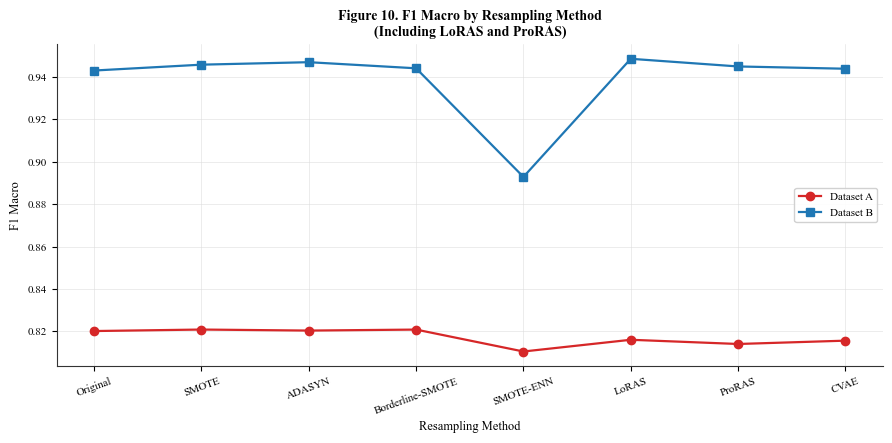

✔ Saved: figures\17_performance_loras_proras_Dataset_A_(UCI).png


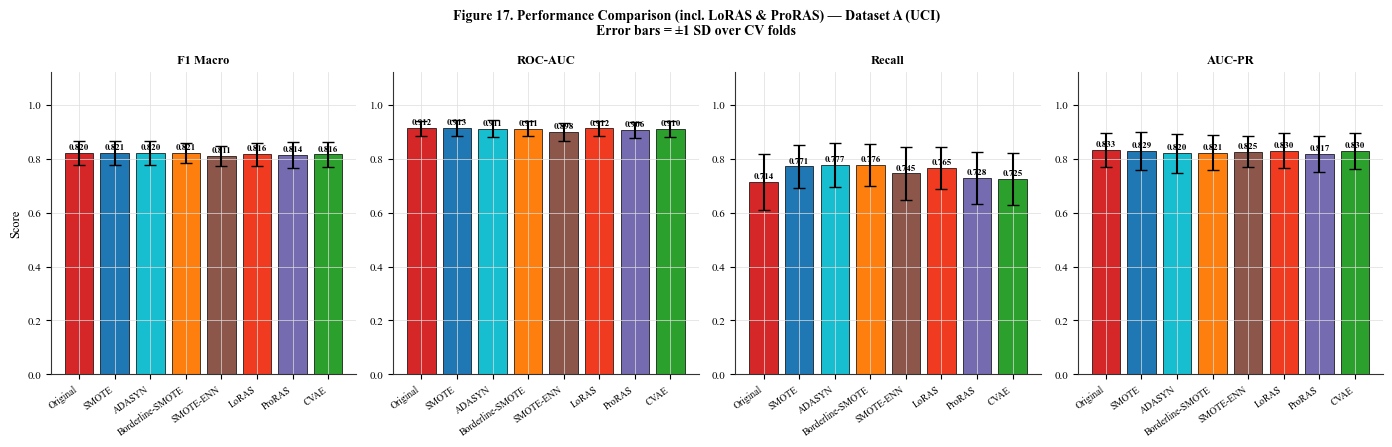

✔ Saved: figures\18_performance_loras_proras_Dataset_B_(Kaggle).png


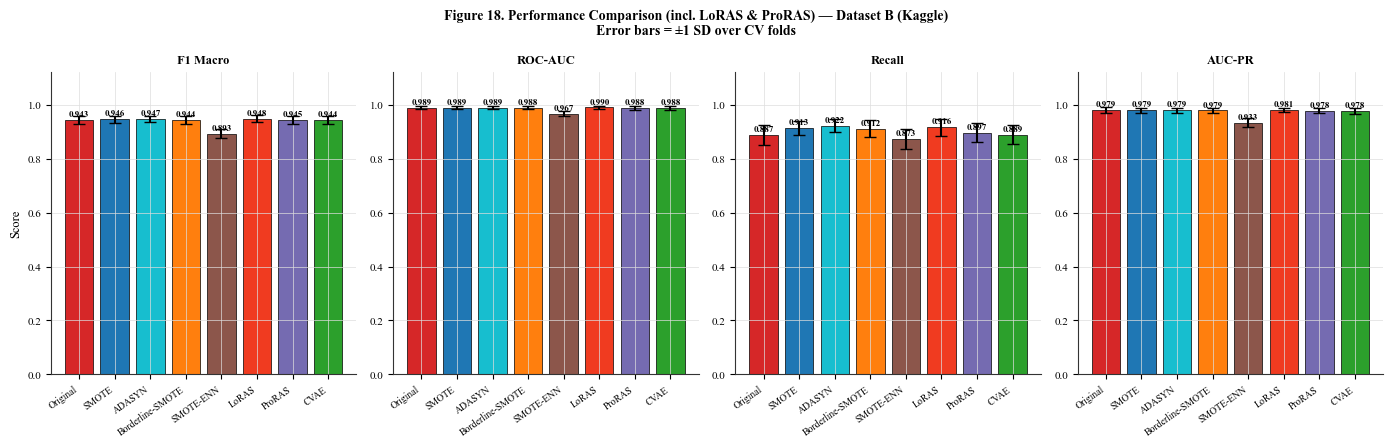


  SIGNIFICANCE: LoRAS / ProRAS vs CVAE and vs each other
  Comparison                                           p-value     Significant    Cohen d  Effect
  ------------------------------------------------------------------------------------------
  Dataset A (UCI) | F1 Macro | CVAE vs LoRAS            0.8611        not sig.    -0.0141  negligible
  Dataset A (UCI) | ROC-AUC | CVAE vs LoRAS             0.2095        not sig.    -0.1945  negligible
  Dataset A (UCI) | F1 Macro | CVAE vs ProRAS           0.7224        not sig.    +0.0552  negligible
  Dataset A (UCI) | ROC-AUC | CVAE vs ProRAS            0.0591        not sig.    +0.3247  small
  Dataset A (UCI) | F1 Macro | LoRAS vs ProRAS          0.7662        not sig.    +0.0625  negligible
  Dataset A (UCI) | ROC-AUC | LoRAS vs ProRAS           0.0034     significant    +0.4321  small
  Dataset A (UCI) | F1 Macro | SMOTE vs LoRAS           0.1407        not sig.    +0.1508  negligible
  Dataset A (UCI) | ROC-AUC | SMOTE vs LoRAS   

In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — CALLING BLOCK
# Run this after your existing results_A / results_B are loaded
# (or after re-running run_pipeline for both datasets).
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # ── 1. Re-run pipeline WITH LoRAS + ProRAS ─────────────────
    # Uncomment the block below if you need to regenerate results.
    # It will add LoRAS and ProRAS keys to the existing dicts.
    #
    # import pickle
    # with open("results_A_full.pkl", "rb") as f:
    #     results_A = pickle.load(f)
    # with open("results_B_full.pkl", "rb") as f:
    #     results_B = pickle.load(f)
    #
    # for ds_name, results_dict, path in [
    #     ("Dataset A", results_A, DATASETS["Dataset A (UCI - Small)"]),
    #     ("Dataset B", results_B, DATASETS["Dataset B (Kaggle - Large)"]),
    # ]:
    #     X, y, _, _ = load_and_preprocess(path)
    #     for method_name, fn in [("LoRAS", apply_loras),
    #                              ("ProRAS", apply_proras)]:
    #         print(f"Running {method_name} on {ds_name} ...")
    #         results_dict[method_name] = run_experiment(X, y, method_name, fn)
    #
    # # Save updated results
    # with open("results_A_full.pkl", "wb") as f:
    #     pickle.dump(results_A, f)
    # with open("results_B_full.pkl", "wb") as f:
    #     pickle.dump(results_B, f)

    # ── 2. Extend colour palette ───────────────────────────────
    METHOD_COLORS["LoRAS"]  = "#F03B20"
    METHOD_COLORS["ProRAS"] = "#756BB1"

    # ── 3. Figures ─────────────────────────────────────────────
    fig_f1_line_comparison(results_A, results_B,
                           metric="F1 Macro", fig_id=10)

    fig_performance_extended(results_A, "Dataset A (UCI)",    fig_id=17)
    fig_performance_extended(results_B, "Dataset B (Kaggle)", fig_id=18)

    # ── 4. Significance tests ───────────────────────────────────
    run_loras_proras_significance(results_A, results_B)

    # ── 5. Aggregate summary table ─────────────────────────────
    print("\n=== Aggregate Results — Dataset A ===")
    print(aggregate_results(results_A).to_string())
    print("\n=== Aggregate Results — Dataset B ===")
    print(aggregate_results(results_B).to_string())

In [20]:
# =============================================================
# EXPLAINABLE AI (XAI) — SHAP Analysis
# Heart Failure Clinical Records — Dual Dataset Study
#
# PASTE THIS AS ONE OR MORE CELLS after your existing pipeline.
# Prerequisites already in scope:
#   results_A, results_B, X_A, y_A, features_A,
#   X_B, y_B, features_B, apply_smote, apply_loras, apply_proras,
#   FIGURES_DIR, save_current, MDPI rcParams, MinMaxScaler
#
# Install (once):  !pip install shap
# =============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings, os
warnings.filterwarnings("ignore")

shap.initjs()   # enable JS in Jupyter (harmless outside Jupyter)

# ── SHAP colour map (consistent with MDPI palette) ────────────
_SHAP_CMAP = LinearSegmentedColormap.from_list(
    "shap_rdb", ["#1F77B4", "#ffffff", "#D62728"]
)

In [21]:
# =============================================================
# HELPER — train one RF on full scaled data, return model + scaler
# =============================================================
def _train_rf_for_shap(X, y, seed=42):
    scaler  = MinMaxScaler()
    X_sc    = scaler.fit_transform(X)
    model   = RandomForestClassifier(n_estimators=300,
                                     random_state=seed,
                                     n_jobs=-1)
    model.fit(X_sc, y)
    return model, scaler, X_sc


In [22]:
# =============================================================
# HELPER — compute SHAP values (TreeExplainer for RF)
# =============================================================
def _shap_values(model, X_sc, feature_names, max_display=None):
    """
    Returns
    -------
    explainer      : shap.TreeExplainer
    shap_vals_pos  : ndarray (n_samples, n_features)
                     SHAP values for the positive class (death=1)
    X_df           : pd.DataFrame with feature names
    """
    explainer     = shap.TreeExplainer(model)
    shap_exp      = explainer(X_sc)          # Explanation object (shap >= 0.40)

    # shap_exp.values shape: (n, features, classes) for multi-class RF
    if shap_exp.values.ndim == 3:
        shap_vals_pos = shap_exp.values[:, :, 1]   # class 1 (Death)
    else:
        shap_vals_pos = shap_exp.values

    X_df = pd.DataFrame(X_sc, columns=feature_names)
    return explainer, shap_vals_pos, shap_exp, X_df

In [23]:
# =============================================================
# FIGURE A — Global Bar: Mean |SHAP| per feature (both datasets)
# =============================================================
def fig_shap_bar(shap_vals_A, shap_vals_B, features_A, features_B,
                 fig_id="XAI-1"):
    """Mean absolute SHAP value per feature — side-by-side for A and B."""

    def _mean_abs(sv, feat):
        s = pd.Series(np.abs(sv).mean(axis=0), index=feat).sort_values(ascending=True)
        return s

    s_A = _mean_abs(shap_vals_A, features_A)
    s_B = _mean_abs(shap_vals_B, features_B)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, series, title, color in [
        (axes[0], s_A, "Dataset A (UCI — Small)",   "#D62728"),
        (axes[1], s_B, "Dataset B (Kaggle — Large)", "#1F77B4"),
    ]:
        bars = ax.barh(series.index, series.values,
                       color=color, alpha=0.85, edgecolor="black",
                       linewidth=0.5)
        for bar, v in zip(bars, series.values):
            ax.text(v + 0.001, bar.get_y() + bar.get_height() / 2,
                    f"{v:.4f}", va="center", fontsize=7.5)
        ax.set_xlabel("Mean |SHAP value|", fontsize=9)
        ax.set_title(title, fontsize=9, fontweight="bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"Figure {fig_id}. Global Feature Importance via SHAP\n"
        "(Mean Absolute SHAP Value — Random Forest on Full Dataset)",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id}_shap_global_bar")
    plt.show()


# =============================================================
# FIGURE B — Beeswarm / Summary Plot  (one per dataset)
# =============================================================
def fig_shap_beeswarm(shap_exp, X_df, dataset_label, fig_id="XAI-2"):
    """
    SHAP beeswarm: each dot = one sample,
    x = SHAP value, colour = feature value.
    """
    # Build a compatible Explanation object with class-1 SHAP values
    if shap_exp.values.ndim == 3:
        sv = shap_exp.values[:, :, 1]
    else:
        sv = shap_exp.values

    exp = shap.Explanation(
        values          = sv,
        base_values     = (shap_exp.base_values[:, 1]
                           if shap_exp.base_values.ndim == 2
                           else shap_exp.base_values),
        data            = shap_exp.data,
        feature_names   = list(X_df.columns),
    )

    fig, ax = plt.subplots(figsize=(9, 5.5))
    plt.sca(ax)
    shap.plots.beeswarm(exp, max_display=12, show=False,
                        color=plt.get_cmap("RdBu_r"))
    ax.set_title(
        f"Figure {fig_id}. SHAP Beeswarm — {dataset_label}\n"
        "(Positive SHAP → increases Death risk | "
        "Colour = feature value: red=high, blue=low)",
        fontsize=9, fontweight="bold"
    )
    plt.tight_layout()
    save_current(f"{fig_id}_shap_beeswarm_{dataset_label.replace(' ', '_')}")
    plt.show()


# =============================================================
# FIGURE C — SHAP Dependence Plots (top-4 features)
# =============================================================
def fig_shap_dependence(shap_vals, X_df, dataset_label, fig_id="XAI-4",
                         n_top=4):
    """
    Dependence plot for the top-N most important features.
    Colour = feature with strongest interaction.
    """
    importance = pd.Series(
        np.abs(shap_vals).mean(axis=0), index=X_df.columns
    ).sort_values(ascending=False)
    top_feats = importance.index[:n_top].tolist()

    fig, axes = plt.subplots(1, n_top, figsize=(14, 4))
    fig.suptitle(
        f"Figure {fig_id}. SHAP Dependence Plots — {dataset_label}\n"
        f"Top {n_top} features by mean |SHAP|",
        fontsize=10, fontweight="bold"
    )

    for ax, feat in zip(axes, top_feats):
        shap.dependence_plot(
            feat,
            shap_vals,
            X_df,
            ax          = ax,
            show        = False,
            dot_size    = 18,
            alpha       = 0.7,
        )
        ax.set_title(feat, fontsize=8, fontweight="bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    save_current(
        f"{fig_id}_shap_dependence_{dataset_label.replace(' ', '_')}"
    )
    plt.show()


# =============================================================
# FIGURE D — SHAP Heatmap  (feature × sample interaction grid)
# =============================================================
def fig_shap_heatmap(shap_exp, X_df, dataset_label, fig_id="XAI-5",
                      max_display=12, n_samples=200):
    """
    Heatmap where rows = features, columns = samples,
    colour = SHAP value. Samples sorted by predicted risk.
    """
    if shap_exp.values.ndim == 3:
        sv = shap_exp.values[:, :, 1]
        bv = (shap_exp.base_values[:, 1]
              if shap_exp.base_values.ndim == 2
              else shap_exp.base_values)
    else:
        sv, bv = shap_exp.values, shap_exp.base_values

    # Sub-sample for readability
    rng = np.random.default_rng(42)
    idx = rng.choice(len(sv), size=min(n_samples, len(sv)), replace=False)
    idx = idx[np.argsort(sv[idx].sum(axis=1))]   # sort by total SHAP

    exp_sub = shap.Explanation(
        values        = sv[idx],
        base_values   = bv[idx],
        data          = shap_exp.data[idx],
        feature_names = list(X_df.columns),
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.sca(ax)
    shap.plots.heatmap(exp_sub, max_display=max_display, show=False)
    ax.set_title(
        f"Figure {fig_id}. SHAP Heatmap — {dataset_label}\n"
        "(Rows = features, Columns = patients sorted by predicted risk; "
        "red = increases risk, blue = decreases risk)",
        fontsize=9, fontweight="bold"
    )
    plt.tight_layout()
    save_current(
        f"{fig_id}_shap_heatmap_{dataset_label.replace(' ', '_')}"
    )
    plt.show()


# =============================================================
# FIGURE E — SHAP across Resampling Methods
#             (how feature ranking shifts per method)
# =============================================================
def fig_shap_method_comparison(X, y, feature_names,
                                resample_methods, dataset_label,
                                fig_id="XAI-6"):
    """
    For each resampling method, trains a RF on the resampled data
    and computes mean |SHAP|.  Plots a heatmap:
      rows = features, columns = methods, colour = normalised importance.
    """
    scaler = MinMaxScaler()
    X_sc   = scaler.fit_transform(X)

    importance_matrix = {}

    for method_name, resample_fn in resample_methods.items():
        if resample_fn is None:
            Xr, yr = X_sc, y
        else:
            Xr, yr = resample_fn(X_sc, y, seed=42)

        rf = RandomForestClassifier(n_estimators=200,
                                    random_state=42, n_jobs=-1)
        rf.fit(Xr, yr)

        explainer  = shap.TreeExplainer(rf)
        shap_exp   = explainer(X_sc)           # explain ORIGINAL test dist.

        if shap_exp.values.ndim == 3:
            sv = shap_exp.values[:, :, 1]
        else:
            sv = shap_exp.values

        importance_matrix[method_name] = np.abs(sv).mean(axis=0)
        print(f"  [{dataset_label}] SHAP done for {method_name}")

    df_imp = pd.DataFrame(importance_matrix, index=feature_names)
    # Normalise each method column to [0,1] for visual comparability
    df_norm = df_imp.apply(lambda col: (col - col.min()) /
                            (col.max() - col.min() + 1e-12))
    # Sort rows by mean importance
    df_norm = df_norm.loc[df_imp.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 5.5))
    im = ax.imshow(df_norm.values, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="Normalised Mean |SHAP|")

    ax.set_xticks(range(len(df_norm.columns)))
    ax.set_xticklabels(df_norm.columns, rotation=30,
                       ha="right", fontsize=8)
    ax.set_yticks(range(len(df_norm.index)))
    ax.set_yticklabels(df_norm.index, fontsize=8)

    # Annotate cells
    for i in range(len(df_norm.index)):
        for j in range(len(df_norm.columns)):
            raw_val = df_imp.values[i, j]
            ax.text(j, i, f"{raw_val:.3f}", ha="center", va="center",
                    fontsize=6.5,
                    color="white" if df_norm.values[i, j] > 0.6 else "black")

    ax.set_title(
        f"Figure {fig_id}. SHAP Feature Importance Across Resampling Methods\n"
        f"— {dataset_label}  (colour = normalised mean |SHAP|)",
        fontsize=10, fontweight="bold"
    )
    plt.tight_layout()
    save_current(
        f"{fig_id}_shap_method_heatmap_{dataset_label.replace(' ', '_')}"
    )
    plt.show()
    return df_imp




# =============================================================
# MASTER SHAP RUNNER  — call this to produce all figures
# =============================================================
def run_shap_analysis(X_A, y_A, features_A,
                      X_B, y_B, features_B,
                      resample_methods=None):
    """
    Full SHAP XAI pipeline.

    Parameters
    ----------
    resample_methods : dict {name: fn} or None
        If provided, used in Figure F (method comparison heatmap).
        Default covers Original / SMOTE / LoRAS / ProRAS / CVAE-aug.
    """
    if resample_methods is None:
        resample_methods = {
            "Original":         None,
            "SMOTE":            apply_smote,
            "Borderline-SMOTE": apply_borderline_smote,
            "SMOTE-ENN":        apply_smote_enn,
            "LoRAS":            apply_loras,
            "ProRAS":           apply_proras,
        }

    print("\n" + "="*65)
    print("  SHAP XAI ANALYSIS — Dataset A (UCI)")
    print("="*65)

    # ── Dataset A ──────────────────────────────────────────────
    model_A, scaler_A, X_sc_A = _train_rf_for_shap(X_A, y_A)
    _, shap_vals_A, shap_exp_A, X_df_A = _shap_values(
        model_A, X_sc_A, features_A
    )
    print("  SHAP values computed for Dataset A.")

    print("\n" + "="*65)
    print("  SHAP XAI ANALYSIS — Dataset B (Kaggle)")
    print("="*65)

    # ── Dataset B ──────────────────────────────────────────────
    model_B, scaler_B, X_sc_B = _train_rf_for_shap(X_B, y_B)
    _, shap_vals_B, shap_exp_B, X_df_B = _shap_values(
        model_B, X_sc_B, features_B
    )
    print("  SHAP values computed for Dataset B.")

    # ── Figure A — Global bar ──────────────────────────────────
    print("\n[XAI-1] Global SHAP Bar …")
    fig_shap_bar(shap_vals_A, shap_vals_B,
                 features_A, features_B, fig_id="XAI-1")

    # ── Figure B — Beeswarm ───────────────────────────────────
    print("[XAI-2] Beeswarm …")
    fig_shap_beeswarm(shap_exp_A, X_df_A,
                      "Dataset A (UCI)", fig_id="XAI-2a")
    fig_shap_beeswarm(shap_exp_B, X_df_B,
                      "Dataset B (Kaggle)", fig_id="XAI-2b")

    # ── Figure C — Dependence ─────────────────────────────────
    print("[XAI-4] Dependence plots …")
    fig_shap_dependence(shap_vals_A, X_df_A,
                        "Dataset A (UCI)", fig_id="XAI-4a")
    fig_shap_dependence(shap_vals_B, X_df_B,
                        "Dataset B (Kaggle)", fig_id="XAI-4b")

    # ── Figure D — Heatmap ────────────────────────────────────
    print("[XAI-5] SHAP Heatmap …")
    fig_shap_heatmap(shap_exp_A, X_df_A,
                     "Dataset A (UCI)", fig_id="XAI-5a")
    fig_shap_heatmap(shap_exp_B, X_df_B,
                     "Dataset B (Kaggle)", fig_id="XAI-5b")

    # ── Figure E — Method comparison heatmap ──────────────────
    print("[XAI-6] SHAP across resampling methods …")
    fig_shap_method_comparison(
        X_A, y_A, features_A, resample_methods,
        "Dataset A (UCI)", fig_id="XAI-6a"
    )
    fig_shap_method_comparison(
        X_B, y_B, features_B, resample_methods,
        "Dataset B (Kaggle)", fig_id="XAI-6b"
    )




# =============================================================
# SHAP SUMMARY TABLE — printed to notebook
# =============================================================
def shap_summary_table(shap_vals_A, shap_vals_B,
                        features_A, features_B):
    """Print ranked feature importance table for both datasets."""
    def _rank_df(sv, feats, ds_label):
        s = pd.DataFrame({
            "Feature"       : feats,
            "Mean |SHAP|"   : np.abs(sv).mean(axis=0),
            "Max  |SHAP|"   : np.abs(sv).max(axis=0),
            "Positive SHAP%": (sv > 0).mean(axis=0) * 100,
        }).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)
        s.index += 1
        s["Dataset"] = ds_label
        return s

    df_A = _rank_df(shap_vals_A, features_A, "A (UCI)")
    df_B = _rank_df(shap_vals_B, features_B, "B (Kaggle)")

    for df, label in [(df_A, "Dataset A (UCI — Small)"),
                      (df_B, "Dataset B (Kaggle — Large)")]:
        print(f"\n{'─'*65}")
        print(f"  SHAP Feature Ranking — {label}")
        print(f"{'─'*65}")
        print(df[["Feature", "Mean |SHAP|", "Max  |SHAP|",
                   "Positive SHAP%"]].to_string())
    print(f"\n{'─'*65}")


  SHAP XAI ANALYSIS — Dataset A (UCI)
  SHAP values computed for Dataset A.

  SHAP XAI ANALYSIS — Dataset B (Kaggle)
  SHAP values computed for Dataset B.

[XAI-1] Global SHAP Bar …
✔ Saved: figures\XAI-1_shap_global_bar.png


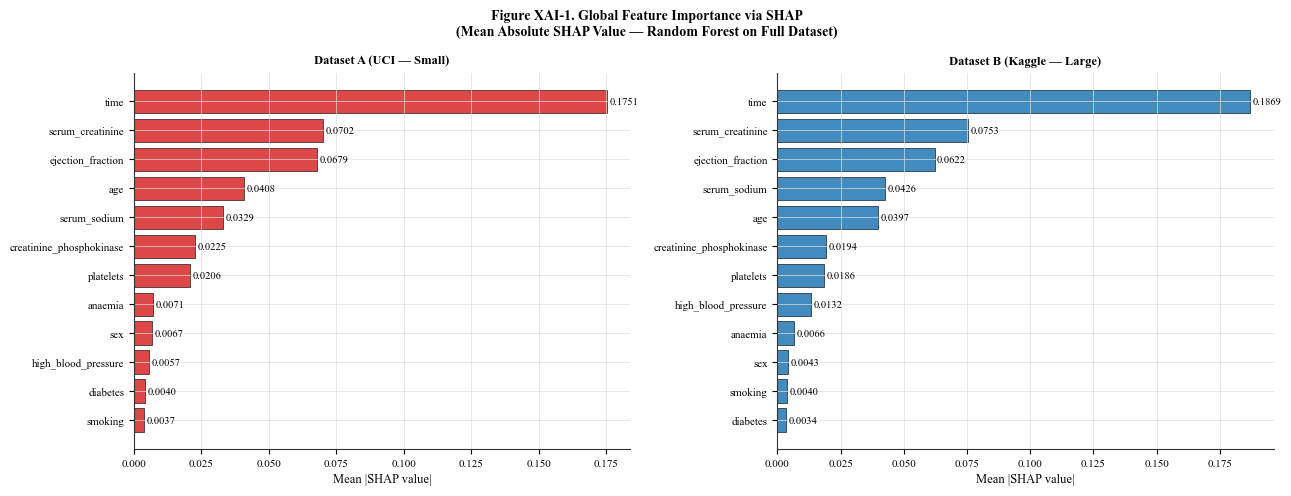

[XAI-2] Beeswarm …
✔ Saved: figures\XAI-2a_shap_beeswarm_Dataset_A_(UCI).png


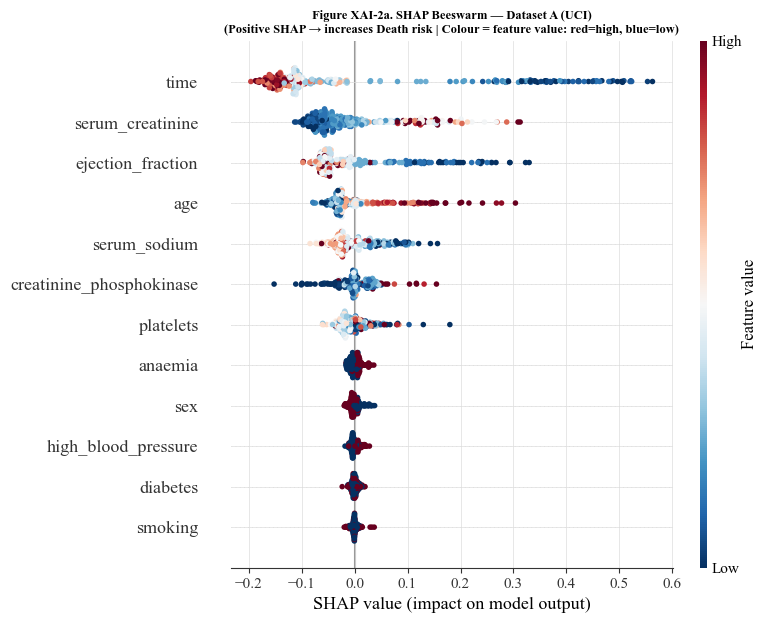

✔ Saved: figures\XAI-2b_shap_beeswarm_Dataset_B_(Kaggle).png


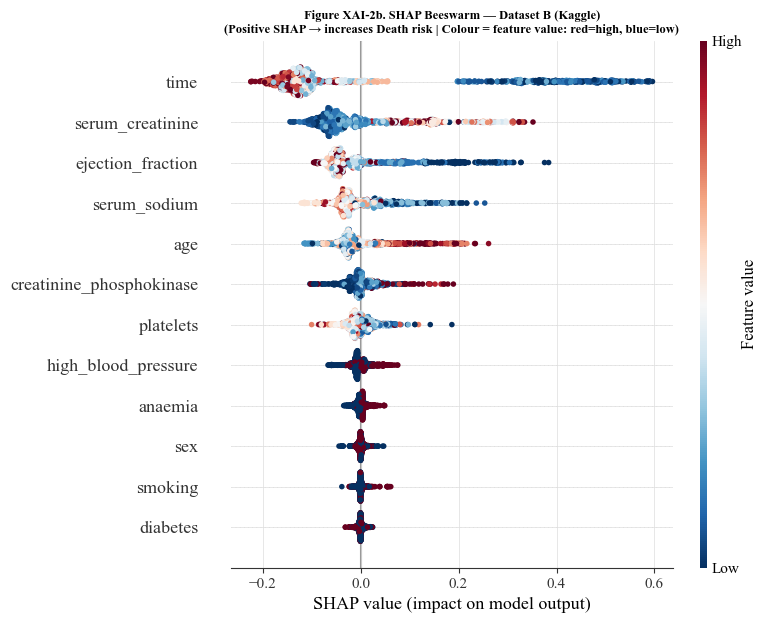

[XAI-4] Dependence plots …
✔ Saved: figures\XAI-4a_shap_dependence_Dataset_A_(UCI).png


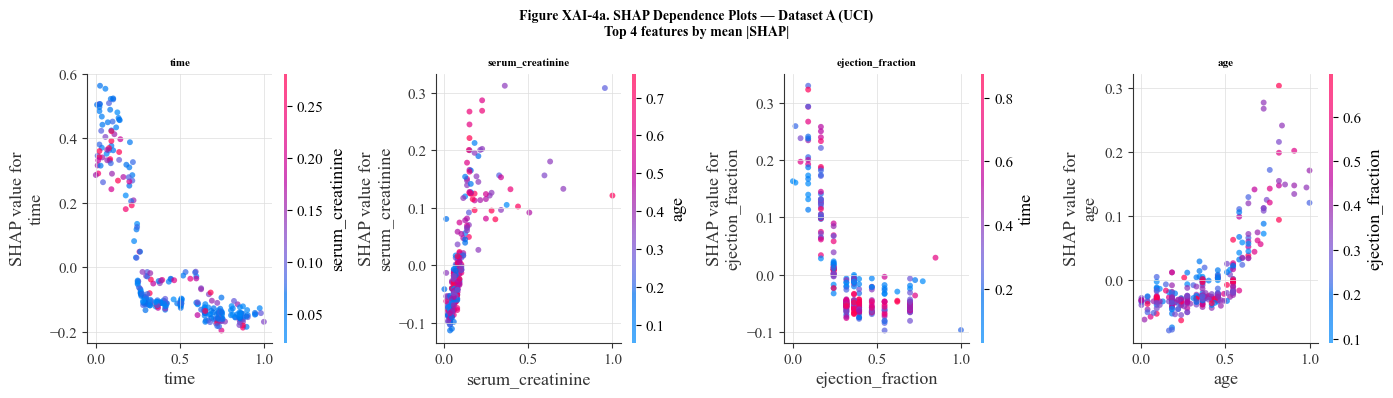

✔ Saved: figures\XAI-4b_shap_dependence_Dataset_B_(Kaggle).png


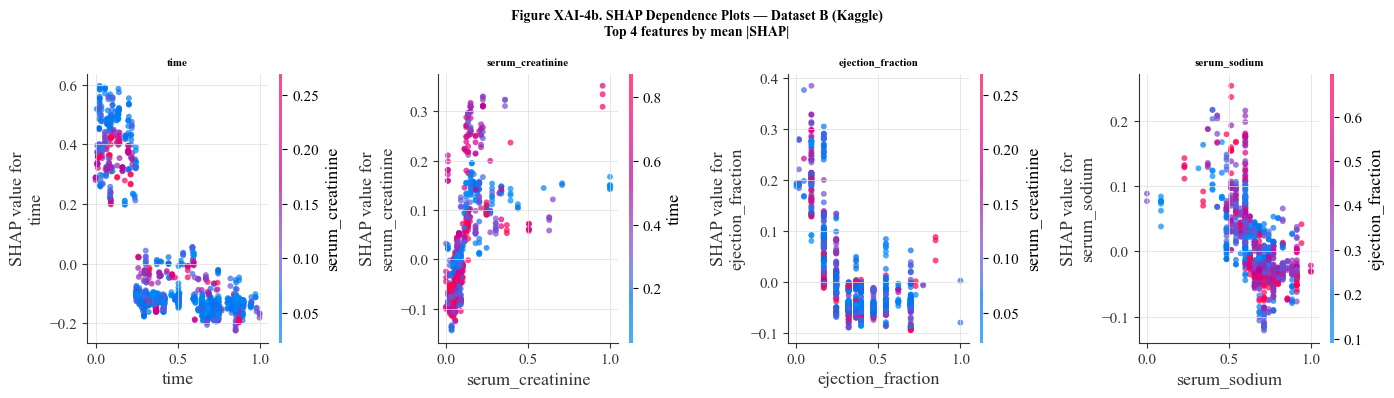

[XAI-5] SHAP Heatmap …
✔ Saved: figures\XAI-5a_shap_heatmap_Dataset_A_(UCI).png


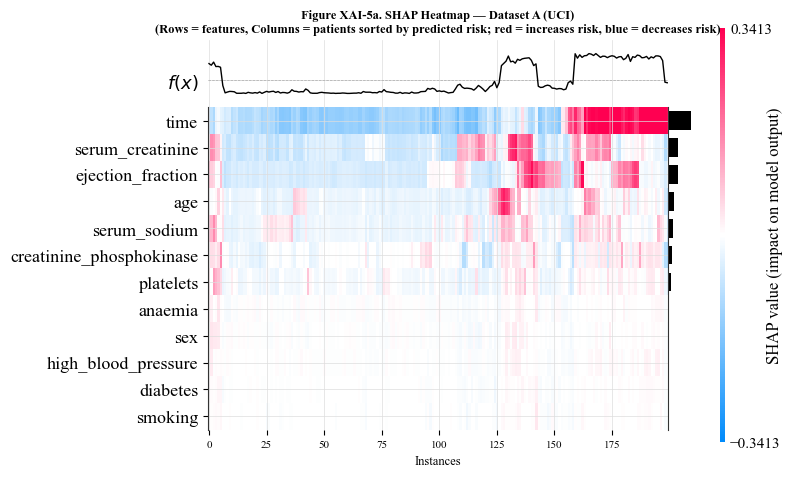

✔ Saved: figures\XAI-5b_shap_heatmap_Dataset_B_(Kaggle).png


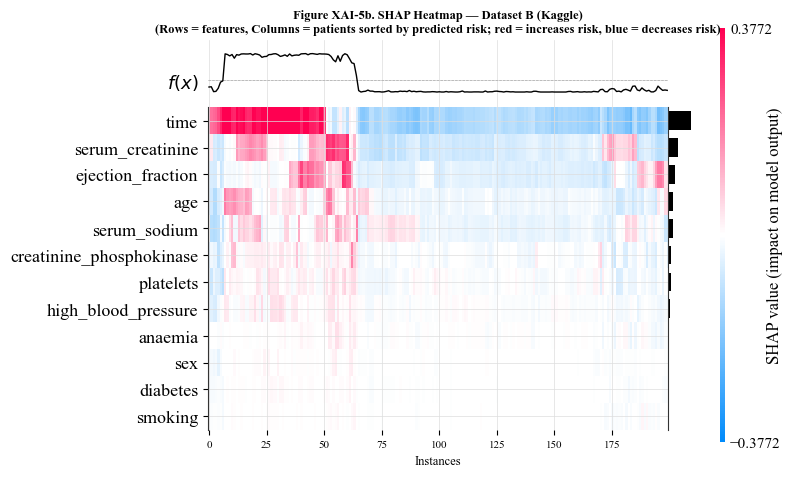

[XAI-6] SHAP across resampling methods …
  [Dataset A (UCI)] SHAP done for Original
  [Dataset A (UCI)] SHAP done for SMOTE
  [Dataset A (UCI)] SHAP done for Borderline-SMOTE
  [Dataset A (UCI)] SHAP done for SMOTE-ENN
  [Dataset A (UCI)] SHAP done for LoRAS
  [Dataset A (UCI)] SHAP done for ProRAS
✔ Saved: figures\XAI-6a_shap_method_heatmap_Dataset_A_(UCI).png


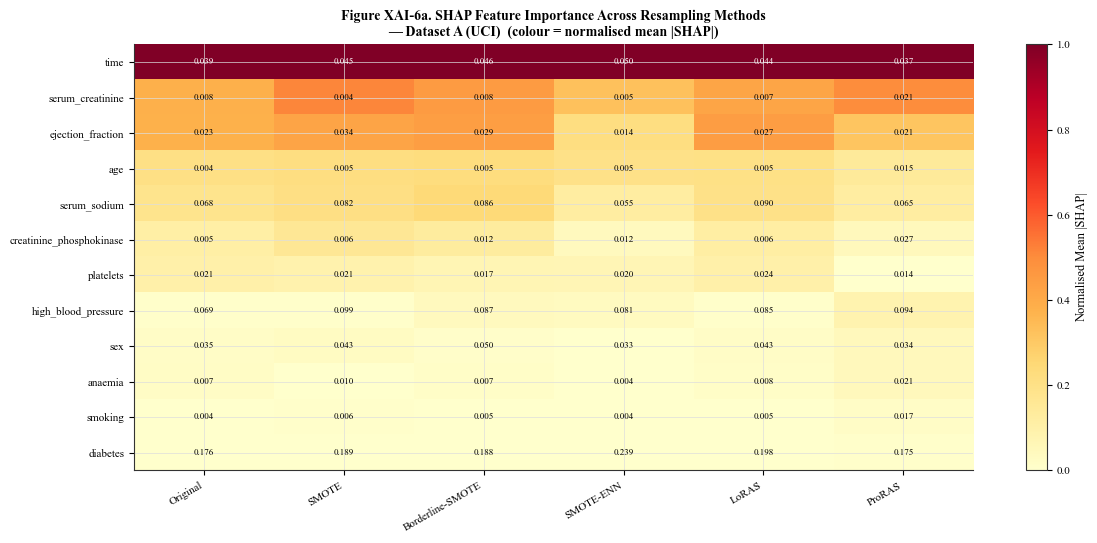

  [Dataset B (Kaggle)] SHAP done for Original
  [Dataset B (Kaggle)] SHAP done for SMOTE
  [Dataset B (Kaggle)] SHAP done for Borderline-SMOTE
  [Dataset B (Kaggle)] SHAP done for SMOTE-ENN
  [Dataset B (Kaggle)] SHAP done for LoRAS
  [Dataset B (Kaggle)] SHAP done for ProRAS
✔ Saved: figures\XAI-6b_shap_method_heatmap_Dataset_B_(Kaggle).png


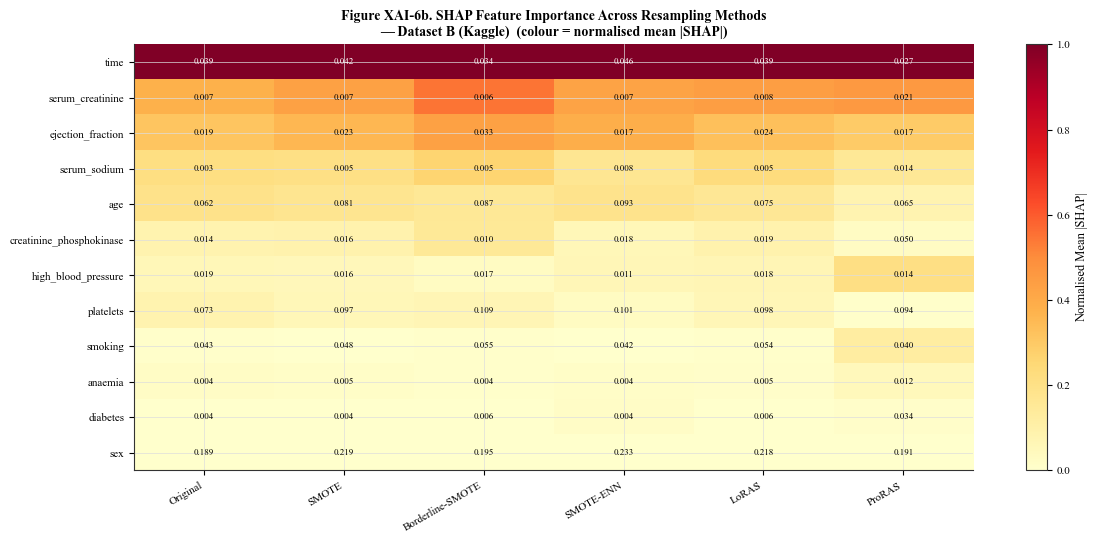

In [26]:
# =============================================================
# ── ENTRY POINT ──────────────────────────────────────────────
# Run this block in your notebook after loading:
#   X_A, y_A, features_A, X_B, y_B, features_B
#   apply_smote, apply_borderline_smote, apply_smote_enn
#   apply_loras, apply_proras   (from previous cells)
# =============================================================

# Run full SHAP analysis
shap_results = run_shap_analysis(
    X_A, y_A, features_A,
    X_B, y_B, features_B,
)